In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

DATA_PATH = Path("../data/synthetic/recovery_events.csv")

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 15)


,transaction_id,customer_id,amount,payment_method,event_type,failure_reason,attempt_number,customer_segment,days_since_failure,previous_success_rate,customer_lifetime_value,is_subscription,invoice_age,recovered,recovery_action
0,TXN_000001,CUST_00268,622.71,upi,invoice_overdue,customer_abandoned,1,loyal,3,0.574,12783.22,0,51,1,retry_payment
1,TXN_000002,CUST_02322,972.79,card,invoice_overdue,bank_timeout,1,regular,8,0.906,14677.03,0,51,0,escalate
2,TXN_000003,CUST_01964,1864.64,upi,checkout_abandoned,authentication_failed,1,loyal,2,0.742,2991.56,0,0,1,retry_payment
3,TXN_000004,CUST_01317,907.38,netbanking,invoice_overdue,customer_abandoned,1,high_value,4,0.924,14749.48,0,52,1,retry_payment
4,TXN_000005,CUST_01300,1200.54,upi,payment_failed,insufficient_funds,1,regular,14,0.873,16575.32,0,0,0,escalate


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape: (10000, 15)

Columns:
['transaction_id', 'customer_id', 'amount', 'payment_method', 'event_type', 'failure_reason', 'attempt_number', 'customer_segment', 'days_since_failure', 'previous_success_rate', 'customer_lifetime_value', 'is_subscription', 'invoice_age', 'recovered', 'recovery_action']

Data types:
transaction_id                 str
customer_id                    str
amount                     float64
payment_method                 str
event_type                     str
failure_reason                 str
attempt_number               int64
customer_segment               str
days_since_failure           int64
previous_success_rate      float64
customer_lifetime_value    float64
is_subscription              int64
invoice_age                  int64
recovered                    int64
recovery_action                str
dtype: object

Missing values:
transaction_id             0
customer_id                0
amount                     0
payment_method             0
event_type    

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,10000,10000,TXN_000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,10000,2875,CUST_00461,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,10000.0,NaN,NaN,NaN,2073.176421,2011.276174,100.0,877.89,1475.85,2557.8875,41531.75
payment_method,10000,4,upi,5484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,10000,4,payment_failed,4455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
failure_reason,10000,8,bank_timeout,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attempt_number,10000.0,NaN,NaN,NaN,1.6877,0.89143,1.0,1.0,1.0,2.0,4.0
customer_segment,10000,4,regular,4018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_since_failure,10000.0,NaN,NaN,NaN,7.0016,4.306025,0.0,3.0,7.0,11.0,14.0
previous_success_rate,10000.0,NaN,NaN,NaN,0.799796,0.120971,0.215,0.727,0.82,0.893,0.999


In [5]:
target_counts = df["recovered"].value_counts()

print(target_counts)
print()
print(
    df["recovered"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

recovered
1    5970
0    4030
Name: count, dtype: int64

recovered
1    59.7
0    40.3
Name: proportion, dtype: float64


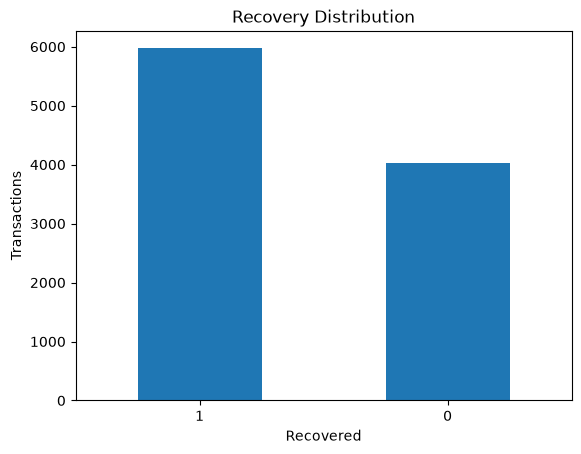

In [6]:
target_counts.plot(kind="bar")

plt.title("Recovery Distribution")
plt.xlabel("Recovered")
plt.ylabel("Transactions")
plt.xticks(rotation=0)
plt.show()

In [7]:
#Total revenue at risk
total_at_risk = df["amount"].sum()

print(f"Total revenue at risk: ₹{total_at_risk:,.2f}")

Total revenue at risk: ₹20,731,764.21


In [8]:
recovered_revenue = df.loc[
    df["recovered"] == 1,
    "amount"
].sum()

print(f"Recovered revenue: ₹{recovered_revenue:,.2f}")

Recovered revenue: ₹12,434,715.75


In [9]:
lost_revenue = df.loc[
    df["recovered"] == 0,
    "amount"
].sum()

print(f"Lost revenue: ₹{lost_revenue:,.2f}")

Lost revenue: ₹8,297,048.46


In [10]:
revenue_recovery_rate = recovered_revenue / total_at_risk

print(
    f"Revenue recovery rate: "
    f"{revenue_recovery_rate:.2%}"
)

Revenue recovery rate: 59.98%


In [11]:
event_analysis = (
    df.groupby("event_type")
    .agg(
        transactions=("transaction_id", "count"),
        recovery_rate=("recovered", "mean"),
        revenue_at_risk=("amount", "sum"),
        revenue_recovered=(
            "amount",
            lambda x: x[df.loc[x.index, "recovered"] == 1].sum()
        ),
    )
    .reset_index()
)

event_analysis["recovery_rate"] *= 100

event_analysis

,event_type,transactions,recovery_rate,revenue_at_risk,revenue_recovered
0,checkout_abandoned,2528,61.511076,5192071.64,3268286.12
1,invoice_overdue,1479,54.428668,3057269.84,1690150.73
2,payment_failed,4455,61.548822,9317498.22,5736833.96
3,subscription_failed,1538,56.436931,3164924.51,1739444.94


In [12]:
failure_analysis = (
    df.groupby("failure_reason")
    .agg(
        transactions=("transaction_id", "count"),
        recovery_rate=("recovered", "mean"),
        avg_amount=("amount", "mean"),
    )
    .sort_values("recovery_rate", ascending=False)
)

failure_analysis["recovery_rate"] *= 100

failure_analysis

,transactions,recovery_rate,avg_amount
failure_reason,,,
network_error,1185,67.510549,2127.735772
bank_timeout,2024,67.144269,2045.918503
unknown,1255,61.673307,2132.516239
limit_exceeded,838,61.575179,2004.509785
mandate_failed,797,60.225847,2037.601719
customer_abandoned,1495,53.511706,2087.293900
authentication_failed,996,51.706827,2017.403494
insufficient_funds,1410,51.489362,2098.981816


In [13]:
attempt_analysis = (
    df.groupby("attempt_number")
    .agg(
        transactions=("transaction_id", "count"),
        recovery_rate=("recovered", "mean"),
        avg_amount=("amount", "mean"),
    )
)

attempt_analysis["recovery_rate"] *= 100

attempt_analysis

,transactions,recovery_rate,avg_amount
attempt_number,,,
1,5541,64.681465,2042.384250
2,2522,56.780333,2113.983826
3,1456,50.549451,2082.141957
4,481,45.322245,2186.792474


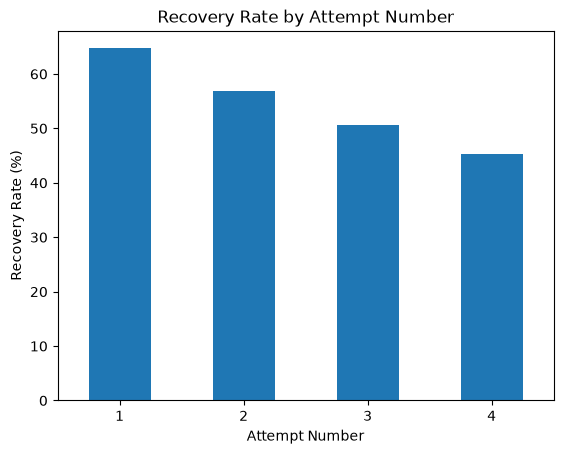

In [14]:
attempt_analysis["recovery_rate"].plot(
    kind="bar"
)

plt.title("Recovery Rate by Attempt Number")
plt.xlabel("Attempt Number")
plt.ylabel("Recovery Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [15]:
segment_analysis = (
    df.groupby("customer_segment")
    .agg(
        customers=("customer_id", "count"),
        recovery_rate=("recovered", "mean"),
        avg_amount=("amount", "mean"),
        total_revenue=("amount", "sum"),
    )
)

segment_analysis["recovery_rate"] *= 100

segment_analysis

,customers,recovery_rate,avg_amount,total_revenue
customer_segment,,,,
high_value,996,66.265060,1952.279930,1944470.81
loyal,2576,61.024845,2088.111964,5378976.42
new,2410,58.921162,2117.476270,5103117.81
regular,4018,57.690393,2066.998300,8305199.17


In [16]:
leakage_candidates = [
    "recovered",
    "recovery_action",
]

print("Potential leakage columns:")
print(leakage_candidates)

Potential leakage columns:
['recovered', 'recovery_action']


In [17]:
FEATURES = [
    "amount",
    "payment_method",
    "event_type",
    "failure_reason",
    "attempt_number",
    "customer_segment",
    "days_since_failure",
    "previous_success_rate",
    "customer_lifetime_value",
    "is_subscription",
    "invoice_age",
]

TARGET = "recovered"

In [18]:
X = df[FEATURES]
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 11)
y shape: (10000,)
